# Actividad 2 - Regresión logística

## Clasificación del sistema operativo de usuarios web

En esta actividad se aplicará un modelo de **regresión logística** para clasificar el sistema operativo utilizado por un usuario que visita un sitio web.

A partir de cuatro características de navegación:

- duración de la visita,
- cantidad de páginas vistas,
- cantidad de acciones realizadas,
- valor de las acciones,

se intentará predecir si el usuario utiliza:

- **0 - Windows**
- **1 - Macintosh**
- **2 - Linux**

El trabajo comprende la preparación y exploración de los datos, el entrenamiento del modelo de clasificación y la evaluación de sus resultados.

## 1. Carga y exploración de los datos

En primer lugar, se importan las librerías necesarias y se carga el dataset para realizar una inspección inicial de los datos.

In [4]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos el dataset
df = pd.read_csv("usuarios_win_mac_lin.csv")

# Mostramos las primeras filas
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [5]:
# Dimensiones del dataset
print("Dimensiones del dataset:", df.shape)

# Información general
print("\nInformación del dataset:")
df.info()

# Valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (170, 5)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB

Valores faltantes por columna:
duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64


## 2. Análisis exploratorio de los datos

Se analizan las principales características del dataset y la distribución de las clases. Además, se exploran las diferencias en el comportamiento de navegación de los usuarios según el sistema operativo utilizado.

In [6]:
# Estadísticas descriptivas
display(df.describe())

# Cantidad de usuarios por sistema operativo
nombres_clases = {
    0: "Windows",
    1: "Macintosh",
    2: "Linux"
}

conteo_clases = df["clase"].value_counts().sort_index()

print("\nDistribución de las clases:")
for clase, cantidad in conteo_clases.items():
    print(f"{clase} - {nombres_clases[clase]}: {cantidad} usuarios")

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000



Distribución de las clases:
0 - Windows: 86 usuarios
1 - Macintosh: 40 usuarios
2 - Linux: 44 usuarios


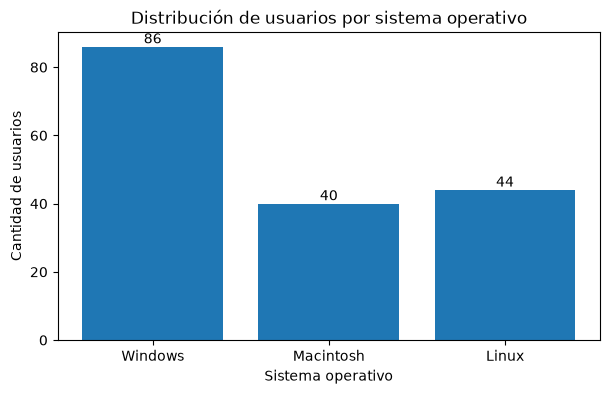

In [7]:
# Preparamos los datos para visualizar las clases
etiquetas = ["Windows", "Macintosh", "Linux"]
cantidades = [conteo_clases[0], conteo_clases[1], conteo_clases[2]]

# Gráfico de barras
plt.figure(figsize=(7, 4))
plt.bar(etiquetas, cantidades)

plt.title("Distribución de usuarios por sistema operativo")
plt.xlabel("Sistema operativo")
plt.ylabel("Cantidad de usuarios")

# Mostramos la cantidad sobre cada barra
for i, cantidad in enumerate(cantidades):
    plt.text(i, cantidad + 1, str(cantidad), ha="center")

plt.show()

In [8]:
# Calculamos el promedio de las características para cada clase
promedios_clase = df.groupby("clase")[
    ["duracion", "paginas", "acciones", "valor"]
].mean()

# Reemplazamos los números de clase por los nombres de los sistemas operativos
promedios_clase.index = promedios_clase.index.map(nombres_clases)

print("Promedio de las características por sistema operativo:")
display(promedios_clase.round(2))

Promedio de las características por sistema operativo:


,duracion,paginas,acciones,valor
clase,,,,
Windows,79.03,2.13,11.47,43.17
Macintosh,156.23,1.95,7.65,38.88
Linux,132.65,1.95,4.34,6.52


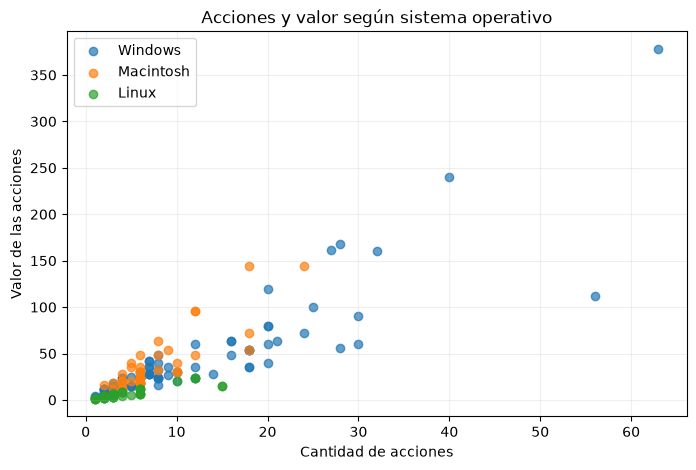

In [9]:
# Separamos los datos por sistema operativo
windows = df[df["clase"] == 0]
macintosh = df[df["clase"] == 1]
linux = df[df["clase"] == 2]

# Gráfico de dispersión: acciones vs valor
plt.figure(figsize=(8, 5))

plt.scatter(windows["acciones"], windows["valor"], label="Windows", alpha=0.7)
plt.scatter(macintosh["acciones"], macintosh["valor"], label="Macintosh", alpha=0.7)
plt.scatter(linux["acciones"], linux["valor"], label="Linux", alpha=0.7)

plt.title("Acciones y valor según sistema operativo")
plt.xlabel("Cantidad de acciones")
plt.ylabel("Valor de las acciones")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 3. Preparación de los datos

Se separan las variables predictoras (`duracion`, `paginas`, `acciones` y `valor`) de la variable objetivo (`clase`). Luego, los datos se dividen en conjuntos de entrenamiento (80 %) y prueba (20 %), manteniendo la proporción de las tres clases.

In [10]:
# Definimos las variables predictoras (X)
X = df[["duracion", "paginas", "acciones", "valor"]]

# Definimos la variable objetivo (y)
y = df["clase"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nPrimeras filas de X:")
display(X.head())

print("\nPrimeros valores de y:")
display(y.head())

Dimensiones de X: (170, 4)
Dimensiones de y: (170,)

Primeras filas de X:


,duracion,paginas,acciones,valor
0,7.0,2,4,8
1,21.0,2,6,6
2,57.0,2,4,4
3,101.0,3,6,12
4,109.0,2,6,12



Primeros valores de y:


0    2
1    2
2    2
3    2
4    2
Name: clase, dtype: int64

In [11]:
# Importamos la función para dividir los datos
from sklearn.model_selection import train_test_split

# Dividimos los datos: 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDatos de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nDistribución de clases en prueba:")
print(y_test.value_counts().sort_index())

Datos de entrenamiento:
X_train: (136, 4)
y_train: (136,)

Datos de prueba:
X_test: (34, 4)
y_test: (34,)

Distribución de clases en entrenamiento:
clase
0    69
1    32
2    35
Name: count, dtype: int64

Distribución de clases en prueba:
clase
0    17
1     8
2     9
Name: count, dtype: int64


## 4. Entrenamiento del modelo

Se crea un modelo de regresión logística y se entrena utilizando el conjunto de entrenamiento. El objetivo es que el modelo aprenda a clasificar los usuarios entre Windows, Macintosh y Linux a partir de sus características de navegación.

In [12]:
# Importamos el modelo de regresión logística
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
modelo = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print("Clases aprendidas:", modelo.classes_)

Modelo entrenado correctamente.
Clases aprendidas: [0 1 2]


## 5. Evaluación del modelo

Una vez entrenado el modelo, se realizan predicciones sobre el conjunto de prueba, compuesto por datos que no fueron utilizados durante el entrenamiento. Su desempeño se analiza mediante la exactitud, la matriz de confusión y el reporte de clasificación.

In [13]:
# Realizamos predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test)

# Comparamos las primeras predicciones con los valores reales
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

# Agregamos los nombres de los sistemas operativos
comparacion["Real_SO"] = comparacion["Real"].map(nombres_clases)
comparacion["Predicho_SO"] = comparacion["Predicho"].map(nombres_clases)

display(comparacion.head(10))

,Real,Predicho,Real_SO,Predicho_SO
0,2,2,Linux,Linux
1,0,2,Windows,Linux
2,2,2,Linux,Linux
3,2,2,Linux,Linux
4,2,2,Linux,Linux
5,0,2,Windows,Linux
6,0,0,Windows,Windows
7,0,2,Windows,Linux
8,2,2,Linux,Linux
9,1,0,Macintosh,Windows


In [14]:
# Importamos la métrica de exactitud
from sklearn.metrics import accuracy_score

# Calculamos la exactitud del modelo
accuracy = accuracy_score(y_test, y_pred)

# Cantidad de predicciones correctas e incorrectas
aciertos = (y_test.values == y_pred).sum()
errores = (y_test.values != y_pred).sum()

print(f"Predicciones correctas: {aciertos} de {len(y_test)}")
print(f"Predicciones incorrectas: {errores} de {len(y_test)}")
print(f"Exactitud (accuracy): {accuracy:.4f}")
print(f"Porcentaje de aciertos: {accuracy * 100:.2f}%")

Predicciones correctas: 25 de 34
Predicciones incorrectas: 9 de 34
Exactitud (accuracy): 0.7353
Porcentaje de aciertos: 73.53%


Matriz de confusión:
[[12  0  5]
 [ 4  4  0]
 [ 0  0  9]]


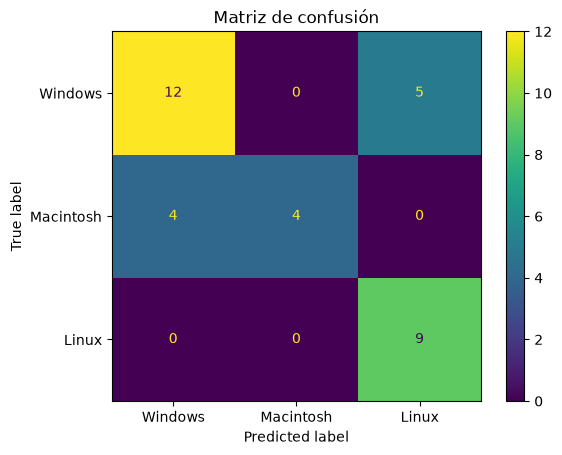

In [15]:
# Importamos la matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz
matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

# Visualizamos la matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Windows", "Macintosh", "Linux"]
)

disp.plot()
plt.title("Matriz de confusión")
plt.show()

In [16]:
# Importamos el reporte de clasificación
from sklearn.metrics import classification_report

# Generamos el reporte
reporte = classification_report(
    y_test,
    y_pred,
    target_names=["Windows", "Macintosh", "Linux"]
)

print("Reporte de clasificación:")
print(reporte)

Reporte de clasificación:
              precision    recall  f1-score   support

     Windows       0.75      0.71      0.73        17
   Macintosh       1.00      0.50      0.67         8
       Linux       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



## 6. Predicción de un nuevo usuario

Finalmente, se utiliza el modelo entrenado para clasificar un nuevo usuario a partir de sus características de navegación y predecir qué sistema operativo utiliza.

In [17]:
# Creamos un nuevo usuario con datos de navegación
nuevo_usuario = pd.DataFrame({
    "duracion": [120],
    "paginas": [2],
    "acciones": [5],
    "valor": [10]
})

# Realizamos la predicción
prediccion = modelo.predict(nuevo_usuario)[0]

# Traducimos la clase numérica al nombre del sistema operativo
sistema_predicho = nombres_clases[prediccion]

print("Datos del nuevo usuario:")
display(nuevo_usuario)

print(f"Sistema operativo predicho: {sistema_predicho}")
print(f"Clase predicha: {prediccion}")

Datos del nuevo usuario:


,duracion,paginas,acciones,valor
0,120,2,5,10


Sistema operativo predicho: Linux
Clase predicha: 2


## Conclusiones

En esta actividad se desarrolló un modelo de **regresión logística** para clasificar el sistema operativo utilizado por los usuarios de un sitio web a partir de cuatro características de navegación: duración de la visita, páginas vistas, cantidad de acciones y valor de las acciones.

El dataset utilizado contiene **170 registros** y no presenta valores faltantes. Para evaluar el modelo, los datos se dividieron en un **80 % para entrenamiento y un 20 % para prueba**, conservando la proporción de las tres clases: Windows, Macintosh y Linux.

El modelo obtuvo una **exactitud del 73,53 %** sobre los datos de prueba, clasificando correctamente **25 de 34 usuarios**.

La matriz de confusión permitió observar que:

- **Linux** fue correctamente identificado en los 9 casos reales de esta clase.
- **Windows** fue correctamente identificado en 12 de 17 casos, mientras que 5 fueron clasificados como Linux.
- **Macintosh** fue correctamente identificado en 4 de 8 casos, mientras que los otros 4 fueron clasificados como Windows.

Estos resultados muestran que el modelo logra distinguir patrones entre los sistemas operativos, aunque presenta mayor dificultad para diferenciar algunos usuarios de **Windows y Macintosh**.

Finalmente, se realizó una predicción sobre un usuario nuevo, demostrando cómo el modelo entrenado puede utilizar las características de navegación para asignar una de las tres clases posibles.

En conclusión, la actividad permitió aplicar el proceso básico de **aprendizaje supervisado para clasificación**, desde la exploración y preparación de los datos hasta el entrenamiento, evaluación y utilización de un modelo de regresión logística.